# Voice Command CNN — Performance Analysis

**Sections:**
1. Model Architecture
2. Training Results
3. Validation Accuracy & Confusion Matrix
4. Per-Class Precision, Recall, F1
5. Mel Spectrogram Visualization
6. Inference Latency Benchmark
7. Confidence Distribution

In [ ]:
import os
import time
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from voice_control.model import VoiceCommandCNN
from voice_control.config import TrainConfig, InferenceConfig
from voice_control.training.dataset import SpeechCommandsDataset, create_dataloaders
from voice_control.audio.processing import preprocess, get_mel_transform, SAMPLE_RATE, N_MELS, NUM_SAMPLES

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("figures", exist_ok=True)

DEVICE = torch.device("cpu")
MODEL_PATH = "./models/voice_command_model.pt"

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
labels = checkpoint["labels"]
num_classes = checkpoint["num_classes"]

model = VoiceCommandCNN(num_classes=num_classes).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Labels: {labels}")
print(f"Best val_acc: {checkpoint['val_acc']:.4f} (epoch {checkpoint['epoch']})")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

## 1. Model Architecture

In [2]:
print(model)
print()

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total:>10,}")
print(f"Trainable parameters: {trainable:>10,}")
print()

for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:.<20s} {params:>8,} params")

VoiceCommandCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats

## 2. Validation Set Evaluation

In [3]:
config = TrainConfig()
_, val_loader = create_dataloaders(config)

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for mel, target in val_loader:
        mel, target = mel.to(DEVICE), target.to(DEVICE)
        logits = model(mel)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

accuracy = (all_preds == all_targets).mean()
print(f"Validation accuracy: {accuracy:.4f} ({(all_preds == all_targets).sum()}/{len(all_targets)})")

Validation accuracy: 0.9644 (3551/3682)


## 3. Confusion Matrix

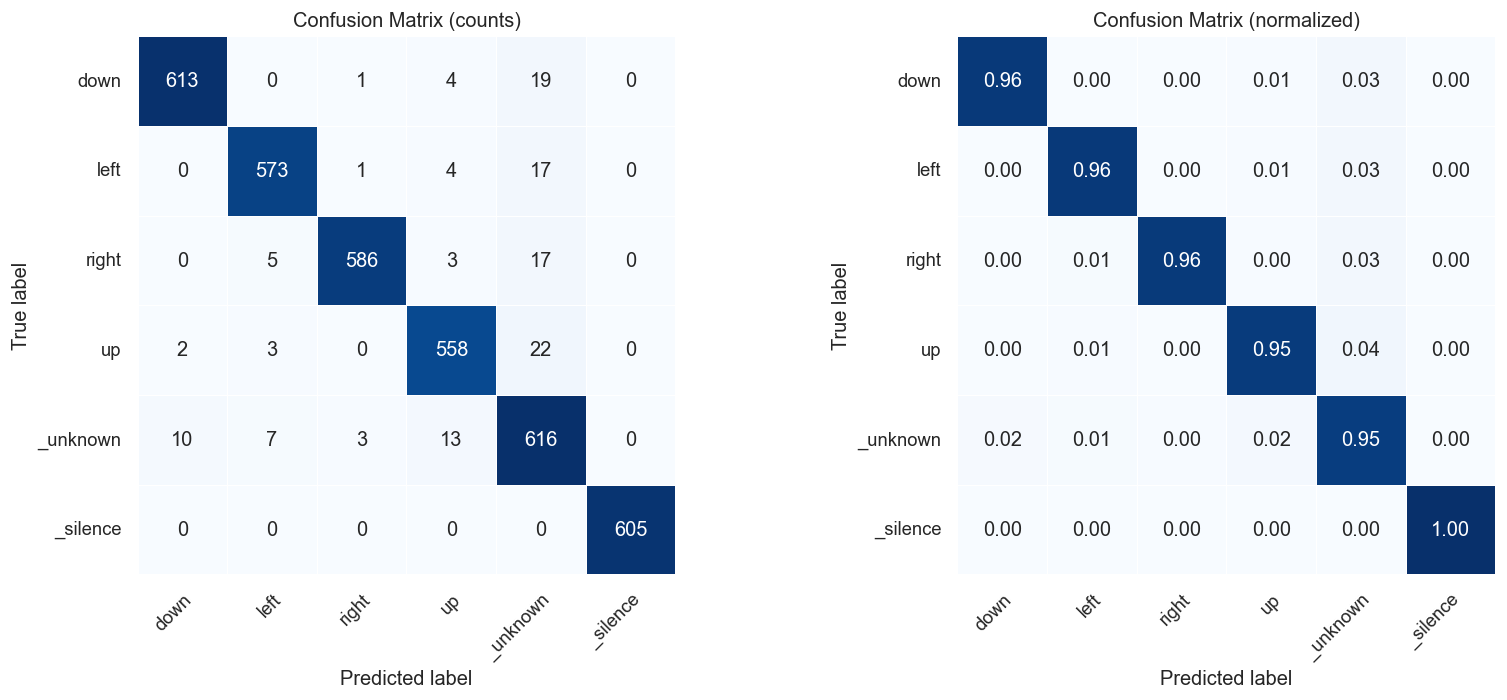

In [4]:
cm = confusion_matrix(all_targets, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=labels, yticklabels=labels, square=True,
    linewidths=0.5, linecolor="white", ax=axes[0],
)
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
    xticklabels=labels, yticklabels=labels, square=True,
    linewidths=0.5, linecolor="white", ax=axes[1],
)
axes[1].set_title("Confusion Matrix (normalized)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", bbox_inches="tight")
plt.show()

## 4. Per-Class Precision, Recall, F1

              precision    recall  f1-score   support

        down       0.98      0.96      0.97       637
        left       0.97      0.96      0.97       595
       right       0.99      0.96      0.98       611
          up       0.96      0.95      0.96       585
    _unknown       0.89      0.95      0.92       649
    _silence       1.00      1.00      1.00       605

    accuracy                           0.96      3682
   macro avg       0.97      0.96      0.97      3682
weighted avg       0.97      0.96      0.96      3682



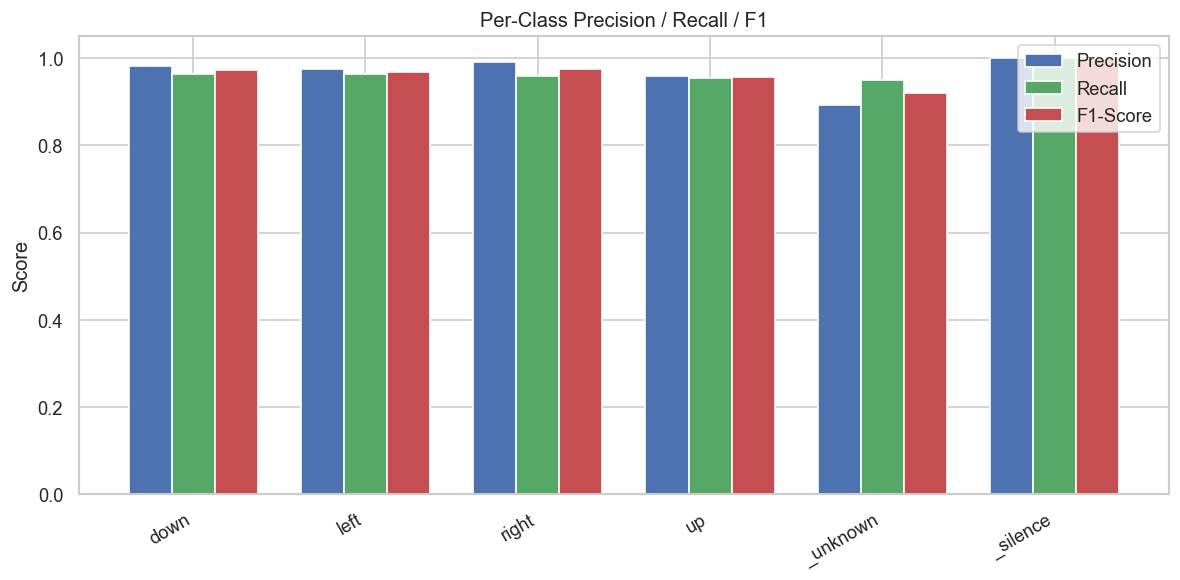

In [5]:
report = classification_report(all_targets, all_preds, target_names=labels, output_dict=True)
print(classification_report(all_targets, all_preds, target_names=labels))

classes = [l for l in labels]
precision = [report[l]["precision"] for l in classes]
recall = [report[l]["recall"] for l in classes]
f1 = [report[l]["f1-score"] for l in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precision, width, label="Precision", color="#4c72b0")
ax.bar(x, recall, width, label="Recall", color="#55a868")
ax.bar(x + width, f1, width, label="F1-Score", color="#c44e52")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.savefig("figures/per_class_metrics.png", bbox_inches="tight")
plt.show()

## 5. Mel Spectrogram Visualization

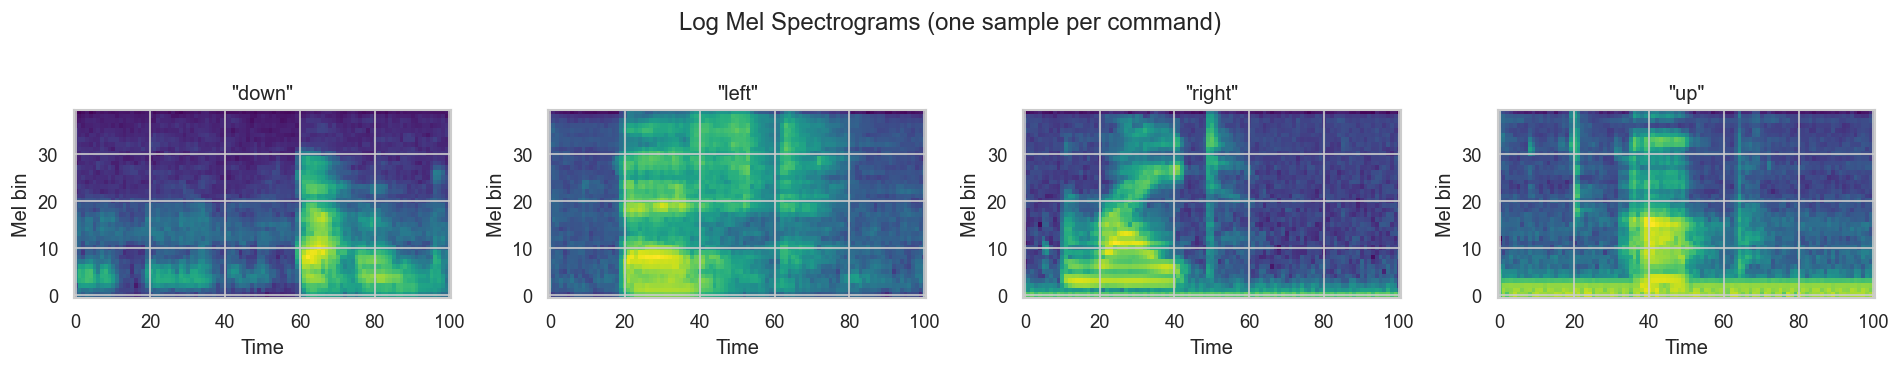

In [6]:
val_dataset = SpeechCommandsDataset(config, augment=False)
mel_transform = get_mel_transform()

command_labels = [l for l in labels if not l.startswith("_")]

fig, axes = plt.subplots(1, len(command_labels), figsize=(4 * len(command_labels), 3))
if len(command_labels) == 1:
    axes = [axes]

for ax, cmd in zip(axes, command_labels):
    label_idx = labels.index(cmd)
    sample_indices = [i for i, (_, l) in enumerate(val_dataset.samples) if l == label_idx]
    if not sample_indices:
        continue
    idx = random.choice(sample_indices)
    mel, _ = val_dataset[idx]

    ax.imshow(mel.squeeze(0).numpy(), aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f'"{cmd}"')
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.suptitle("Log Mel Spectrograms (one sample per command)", y=1.02)
plt.tight_layout()
plt.savefig("figures/mel_spectrograms.png", bbox_inches="tight")
plt.show()

## 6. Inference Latency Benchmark

Inference latency (200 runs):
  Mean:   1.04 ms
  Median: 1.04 ms
  Std:    0.07 ms
  Min:    0.87 ms
  Max:    1.25 ms
  P95:    1.15 ms
  P99:    1.22 ms


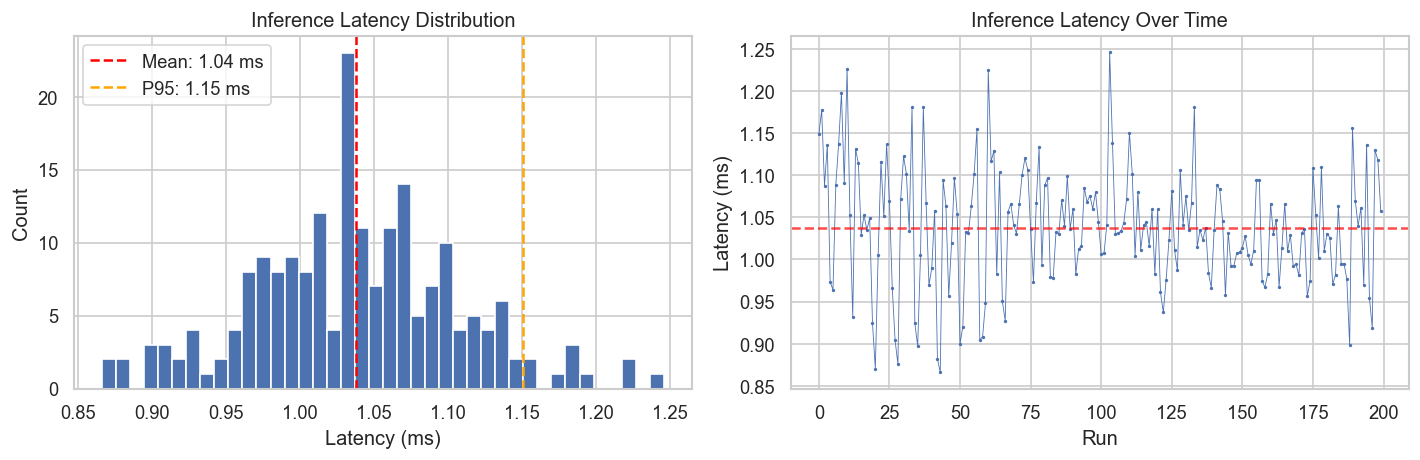

In [7]:
dummy = torch.randn(1, NUM_SAMPLES)
mel = preprocess(dummy, SAMPLE_RATE, mel_transform)
mel = mel.unsqueeze(0).to(DEVICE)

for _ in range(20):
    model(mel)

times = []
for _ in range(200):
    t0 = time.perf_counter()
    model(mel)
    times.append((time.perf_counter() - t0) * 1000)

times = np.array(times)
print(f"Inference latency (200 runs):")
print(f"  Mean:   {times.mean():.2f} ms")
print(f"  Median: {np.median(times):.2f} ms")
print(f"  Std:    {times.std():.2f} ms")
print(f"  Min:    {times.min():.2f} ms")
print(f"  Max:    {times.max():.2f} ms")
print(f"  P95:    {np.percentile(times, 95):.2f} ms")
print(f"  P99:    {np.percentile(times, 99):.2f} ms")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(times, bins=40, color="#4c72b0", edgecolor="white")
axes[0].axvline(times.mean(), color="red", linestyle="--", label=f"Mean: {times.mean():.2f} ms")
axes[0].axvline(np.percentile(times, 95), color="orange", linestyle="--", label=f"P95: {np.percentile(times, 95):.2f} ms")
axes[0].set_xlabel("Latency (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("Inference Latency Distribution")
axes[0].legend()

axes[1].plot(times, marker=".", markersize=2, linewidth=0.5)
axes[1].axhline(times.mean(), color="red", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Run")
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("Inference Latency Over Time")

plt.tight_layout()
plt.savefig("figures/latency_benchmark.png", bbox_inches="tight")
plt.show()

## 7. Confidence Distribution

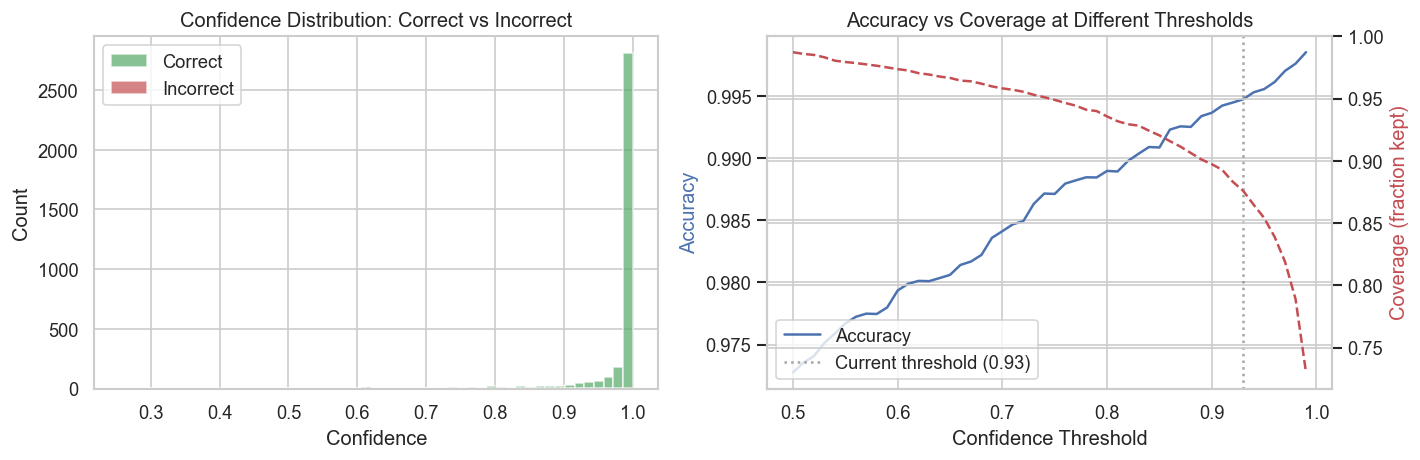

In [8]:
correct_mask = all_preds == all_targets
top_probs = all_probs[np.arange(len(all_preds)), all_preds]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(top_probs[correct_mask], bins=50, alpha=0.7, label="Correct", color="#55a868")
axes[0].hist(top_probs[~correct_mask], bins=50, alpha=0.7, label="Incorrect", color="#c44e52")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")
axes[0].set_title("Confidence Distribution: Correct vs Incorrect")
axes[0].legend()

thresholds = np.arange(0.5, 1.0, 0.01)
accs = []
coverages = []
for t in thresholds:
    mask = top_probs >= t
    if mask.sum() == 0:
        accs.append(np.nan)
        coverages.append(0)
    else:
        accs.append((all_preds[mask] == all_targets[mask]).mean())
        coverages.append(mask.mean())

ax2 = axes[1]
ax2.plot(thresholds, accs, label="Accuracy", color="#4c72b0")
ax2_twin = ax2.twinx()
ax2_twin.plot(thresholds, coverages, label="Coverage", color="#c44e52", linestyle="--")
ax2.set_xlabel("Confidence Threshold")
ax2.set_ylabel("Accuracy", color="#4c72b0")
ax2_twin.set_ylabel("Coverage (fraction kept)", color="#c44e52")
ax2.set_title("Accuracy vs Coverage at Different Thresholds")
ax2.axvline(0.93, color="gray", linestyle=":", alpha=0.7, label="Current threshold (0.93)")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.savefig("figures/confidence_analysis.png", bbox_inches="tight")
plt.show()

## 8. Per-Class Accuracy Bar Chart

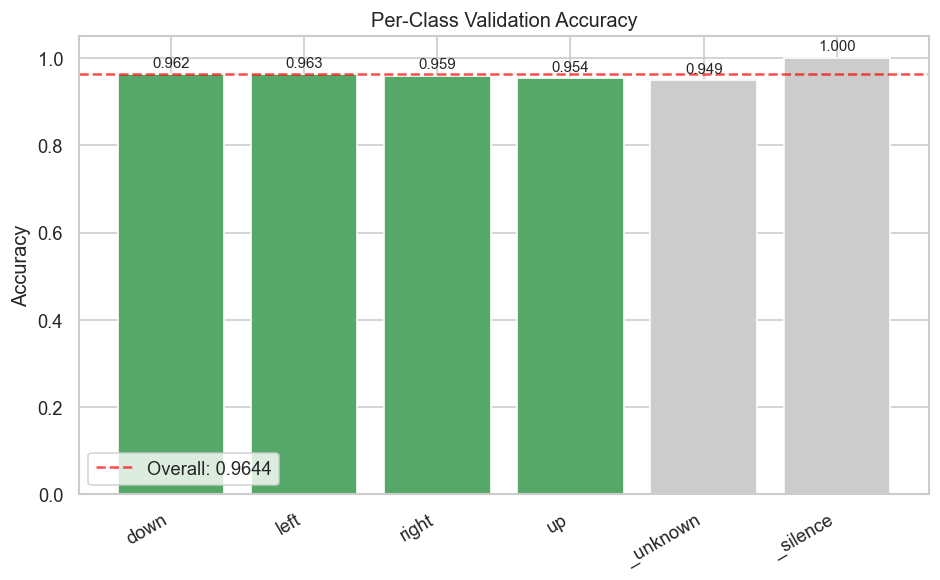

In [9]:
per_class_acc = []
for i, label in enumerate(labels):
    mask = all_targets == i
    if mask.sum() > 0:
        acc = (all_preds[mask] == i).mean()
    else:
        acc = 0
    per_class_acc.append(acc)

colors = ["#55a868" if not l.startswith("_") else "#cccccc" for l in labels]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, per_class_acc, color=colors, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Validation Accuracy")
ax.axhline(accuracy, color="red", linestyle="--", alpha=0.7, label=f"Overall: {accuracy:.4f}")
ax.legend()

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/per_class_accuracy.png", bbox_inches="tight")
plt.show()

## 9. Summary Table

In [10]:
import pandas as pd

summary = {
    "Metric": [
        "Model",
        "Parameters",
        "Training epochs",
        "Best epoch",
        "Validation accuracy",
        "Number of classes",
        "Commands",
        "Sample rate",
        "Mel bins",
        "Input duration",
        "Mean inference (CPU)",
        "P95 inference (CPU)",
        "Confidence threshold",
    ],
    "Value": [
        "VoiceCommandCNN (4-block CNN)",
        f"{total:,}",
        str(TrainConfig().epochs),
        str(checkpoint["epoch"]),
        f"{accuracy:.4f}",
        str(num_classes),
        ", ".join(l for l in labels if not l.startswith("_")),
        f"{SAMPLE_RATE} Hz",
        str(N_MELS),
        "1.0 s",
        f"{times.mean():.2f} ms",
        f"{np.percentile(times, 95):.2f} ms",
        str(InferenceConfig().confidence_threshold),
    ],
}

df = pd.DataFrame(summary)
df.style.hide(axis="index")

Metric,Value
Model,VoiceCommandCNN (4-block CNN)
Parameters,"249,606"
Training epochs,30
Best epoch,21
Validation accuracy,0.9644
Number of classes,6
Commands,"down, left, right, up"
Sample rate,16000 Hz
Mel bins,40
Input duration,1.0 s
